# Import Required Libraries Pandas, Numpy

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import OneHotEncoder
from xgboost import XGBRegressor
from sklearn.feature_selection import mutual_info_regression
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

In [2]:
plt.style.use("seaborn-whitegrid")
plt.rc("figure", autolayout=True)
plt.rc(
    "axes",
    labelweight="bold",
    labelsize="large",
    titleweight="bold",
    titlesize=14,
    titlepad=10,
)

OSError: 'seaborn-whitegrid' is not a valid package style, path of style file, URL of style file, or library style name (library styles are listed in `style.available`)

# Data Cleaning and Exploration

In [2]:
churn_df = pd.read_csv("train.csv")
test_df= pd.read_csv("test.csv")
churn_df.head()


,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,...,Yes,Yes,No,No,One year,Yes,Mailed check,60.10,1653.85,No
1,1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,...,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20,No
2,2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35,No
3,3,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,69.70,70.70,Yes
4,4,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.45,70.45,Yes


In [4]:

churn_df.describe()




,id,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,594194.000000,594194.000000,594194.000000,594194.000000,594194.000000
mean,297096.500000,0.114102,36.577258,65.866223,2494.377057
std,171529.177263,0.317936,25.061922,31.067444,2353.916710
min,0.000000,0.000000,1.000000,18.250000,18.800000
25%,148548.250000,0.000000,12.000000,29.900000,639.650000
50%,297096.500000,0.000000,35.000000,74.100000,1433.650000
75%,445644.750000,0.000000,62.000000,90.800000,4263.800000
max,594193.000000,1.000000,72.000000,118.750000,8684.800000


In [5]:

churn_df.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 594194 entries, 0 to 594193
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                594194 non-null  int64  
 1   gender            594194 non-null  object 
 2   SeniorCitizen     594194 non-null  int64  
 3   Partner           594194 non-null  object 
 4   Dependents        594194 non-null  object 
 5   tenure            594194 non-null  int64  
 6   PhoneService      594194 non-null  object 
 7   MultipleLines     594194 non-null  object 
 8   InternetService   594194 non-null  object 
 9   OnlineSecurity    594194 non-null  object 
 10  OnlineBackup      594194 non-null  object 
 11  DeviceProtection  594194 non-null  object 
 12  TechSupport       594194 non-null  object 
 13  StreamingTV       594194 non-null  object 
 14  StreamingMovies   594194 non-null  object 
 15  Contract          594194 non-null  object 
 16  PaperlessBilling  59

In [6]:
### check for missing values

missing_values = churn_df.isnull().sum()
print(missing_values)

id                  0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [7]:
## check for duplicates
churn_df.duplicated().sum()

np.int64(0)

In [8]:
# Drop Customer id column
churn_df.drop('id',axis=1,inplace=True)
churn_df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,No,Yes,Yes,No,No,One year,Yes,Mailed check,60.10,1653.85,No
1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,Yes,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20,No
2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35,No
3,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,69.70,70.70,Yes
4,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.45,70.45,Yes


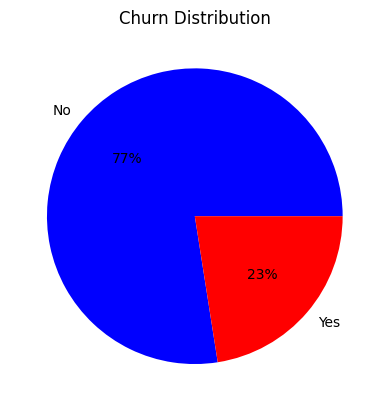

In [9]:
churn_data = churn_df["Churn"].value_counts()

plt.pie(churn_data,labels=churn_data.index,autopct='%1.0f%%', colors=["blue", "red"])
plt.title('Churn Distribution')
plt.show()

In [10]:
churn_data

Churn
No     460377
Yes    133817
Name: count, dtype: int64

## Churn Distribution By Categorical and  Numerical features

In [11]:
## Encode Churn
churn_df['Churn']= churn_df['Churn'].map({
    'Yes': 1,
    'No': 0
})

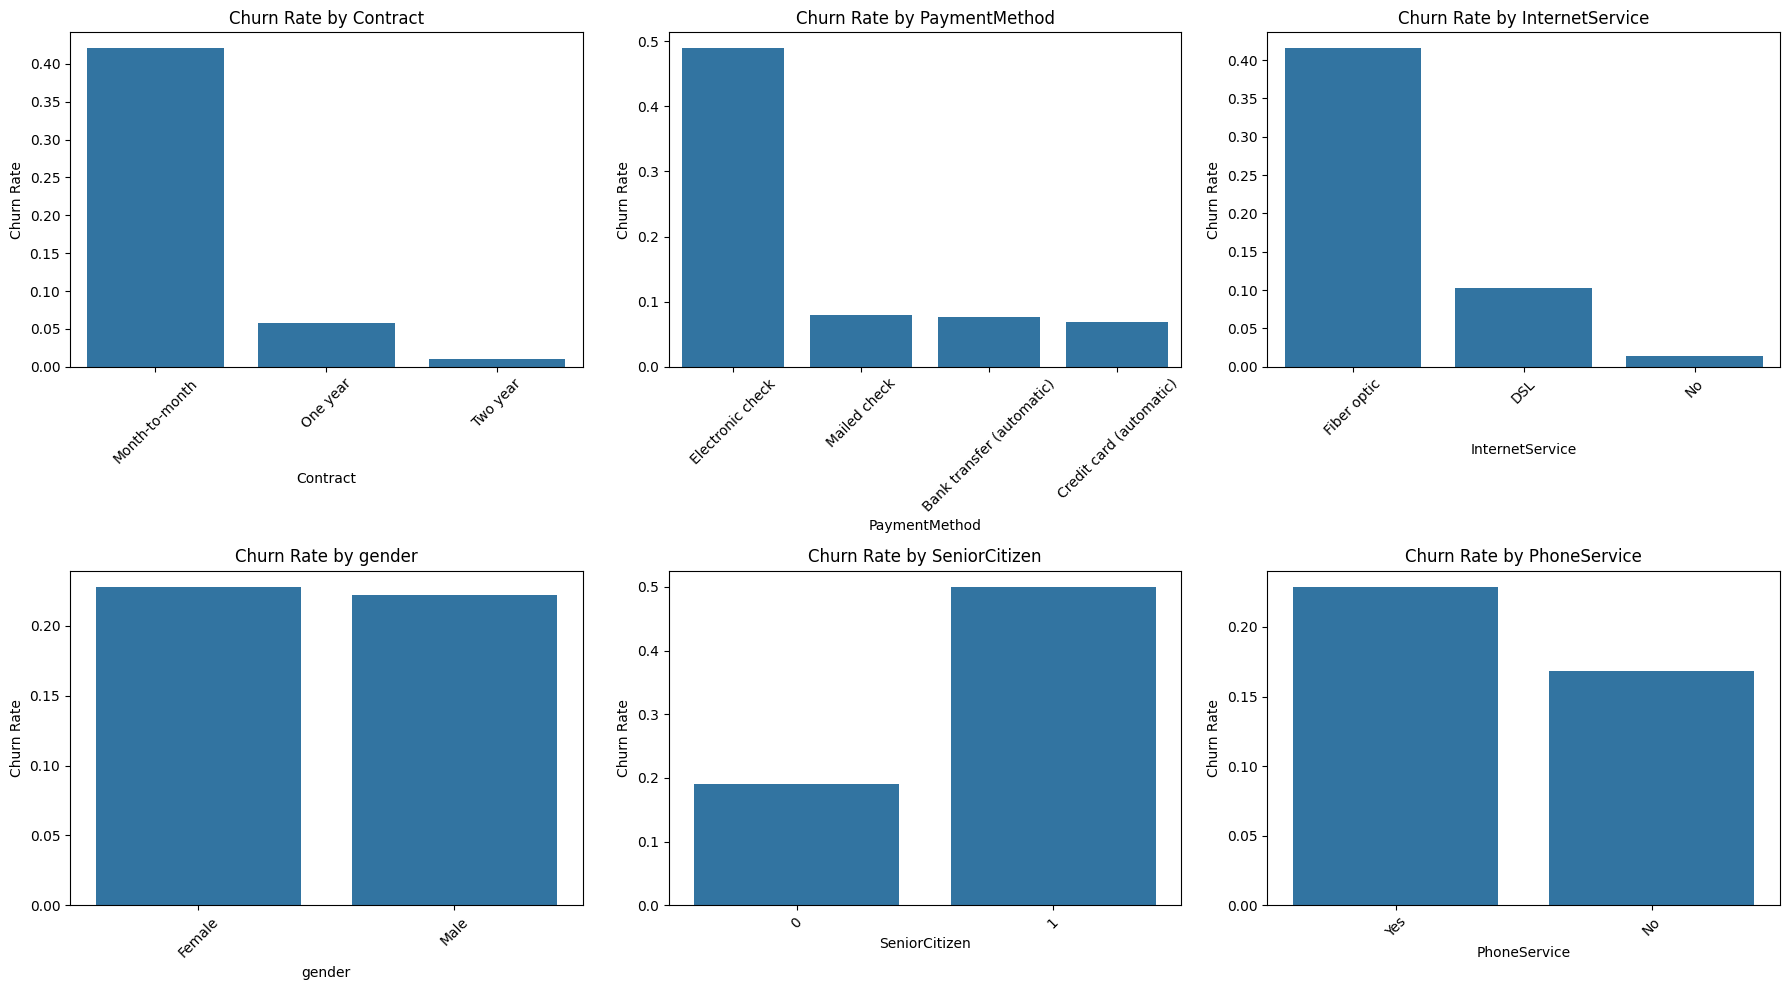

In [12]:
## Churn distribution by Ctegorical Variables
categorical_cols = [
    'Contract',
    'PaymentMethod',
    'InternetService',
    'gender',
    'SeniorCitizen',
    'PhoneService'
]

# Create subplot grid
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Flatten axes for easy iteration
axes = axes.flatten()

for i, col in enumerate(categorical_cols):

    churn_rate = (
        churn_df.groupby(col)['Churn']
        .mean()
        .sort_values(ascending=False)
    )

    sns.barplot(
        x=churn_rate.index,
        y=churn_rate.values,
        ax=axes[i]
    )

    axes[i].set_title(f'Churn Rate by {col}')
    axes[i].set_ylabel("Churn Rate")
    axes[i].tick_params(axis='x', rotation=45)



plt.tight_layout()

plt.show()

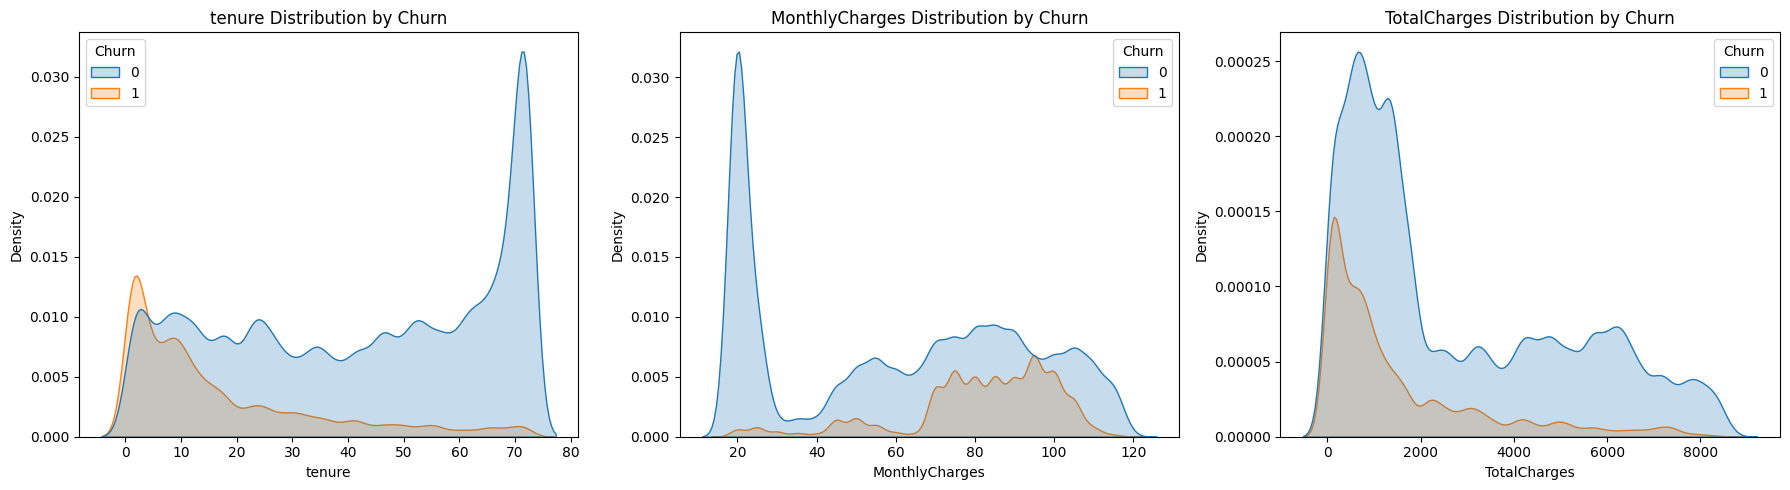

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

numerical_cols = [
    'tenure',
    'MonthlyCharges',
    'TotalCharges'
]

# Create subplot grid
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Flatten axes
axes = axes.flatten()

for i, col in enumerate(numerical_cols):

    sns.kdeplot(
        data=churn_df,
        x=col,
        hue='Churn',
        fill=True,
        ax=axes[i]
    )

    axes[i].set_title(f'{col} Distribution by Churn')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Density")

plt.tight_layout()

plt.show()

## Separate the target from the features

In [15]:

X = churn_df.drop(columns=['Churn'])
y = churn_df['Churn']

## Separate Columns by type

In [19]:
categorical_cols = X.select_dtypes(include=['object']).columns

numeric_cols = X.select_dtypes(exclude=['object']).columns


## Preprocessing Pipeline


# Feature Engineering


## Numeric Features

In [20]:
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

## Categorical Features

In [22]:
categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

## Combine features
preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_cols),
    ('cat', categorical_transformer, categorical_cols)
])

## Train-Test Split

In [44]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# Define Models

## Logistic Regression

In [24]:
lr_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=1000))
])

## Random Forest

In [25]:
rf_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        random_state=42
    ))
])

## XGBoost

In [26]:
xgb_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', XGBClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=6,
        random_state=42,
        eval_metric='logloss'
    ))
])

## LightGBM

In [27]:
lgbm_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LGBMClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=6,
        random_state=42
    ))
])

## Model Evaluation

In [31]:
def evaluate_model(name, model):

    model.fit(X_train, y_train)

    preds = model.predict(X_valid)

    probs = model.predict_proba(X_valid)[:,1]

    results = {
        'Model': name,
        'Accuracy': accuracy_score(y_valid, preds),
        'Precision': precision_score(y_valid, preds),
        'Recall': recall_score(y_valid, preds),
        'F1': f1_score(y_valid, preds),
        'ROC_AUC': roc_auc_score(y_valid, probs)
    }

    return results

## Compare Models

In [32]:
results = pd.DataFrame([

    evaluate_model("Logistic Regression", lr_model),

    evaluate_model("Random Forest", rf_model),

    evaluate_model("XGBoost", xgb_model),

    evaluate_model("LightGBM", lgbm_model)

])

results.sort_values(by='ROC_AUC', ascending=False)



[LightGBM] [Info] Number of positive: 107054, number of negative: 368301
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.040542 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 668
[LightGBM] [Info] Number of data points in the train set: 475355, number of used features: 45
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.225209 -> initscore=-1.235567
[LightGBM] [Info] Start training from score -1.235567


C:\Users\TOM\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\TOM\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,Model,Accuracy,Precision,Recall,F1,ROC_AUC
2,XGBoost,0.859894,0.709162,0.640586,0.673132,0.915657
3,LightGBM,0.859718,0.708237,0.641258,0.673086,0.915450
1,Random Forest,0.856091,0.698843,0.634346,0.665034,0.911883
0,Logistic Regression,0.854416,0.683671,0.657998,0.670589,0.908428


### Churn datasets are typically imbalanced and so is this one. Majority of the customers tend not to churn with only a significant small portion churning. Due to this imbalance, techniques such as under and oversampling, SMOTE(Synthetic Minority Oversampling) are used. To assess the viability of our model, accuracy isn't applicable as it's unreliable on imbalanced datasets. Metrics and methods such as precision, recall and f1-score will be used.

## Predict Churn Probabilities

In [45]:
#xgb_model.fit(X, y)
xgb_model.fit(X_train, y_train)


test_probs = xgb_model.predict_proba(test_df)[:,1]

# Explainable AI using SHAP

## SHAP (SHapley Additive exPlanations) explains:

### Why the model predicts churn
### Which features increase/decrease churn probability
### Global vs individual drivers of churn

### Transform Validation Data

In [53]:

X_valid_transformed = (
    xgb_model.named_steps['preprocessor']
    .transform(X_valid)
)


## Get Feature Names

In [55]:
feature_names = (
    xgb_model.named_steps['preprocessor']
    .get_feature_names_out()
)
## Covert to DataFrame
X_valid_shap = pd.DataFrame(
    X_valid_transformed,
    columns=feature_names
)

## Extract rained Model

In [57]:
trained_xgb = xgb_model.named_steps['model']

## Sample Data for afster SHAP compuattion
X_sample = X_valid_shap.sample(
    500,
    random_state=42
)

## Compute SHAP Values

In [59]:
## Create SHAP Explainer


explainer = shap.Explainer(
    trained_xgb.predict,
    X_sample
)


# Generate SHAP values
shap_values = explainer(X_sample)



PermutationExplainer explainer: 501it [01:09,  6.11it/s]                                  


In [ ]:
## Global Feature Importance

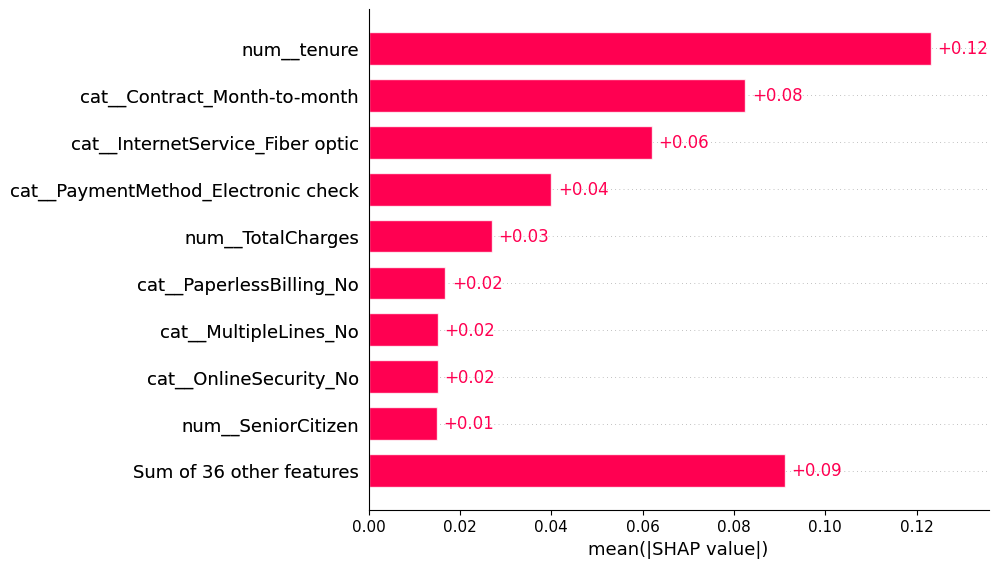

In [60]:
shap.plots.bar(shap_values)

plt.show()


In [ ]:
Feature	Interpretation
tenure	strongest churn driver
low tenure customers push strongly toward churn
long-tenure customers reduce churn
Contract_Month-to-month	high churn risk
month-to-month contracts strongly increase churn risk
MonthlyCharges	pricing pressure
higher charges increase churn probability

## Detailed Feature Impact

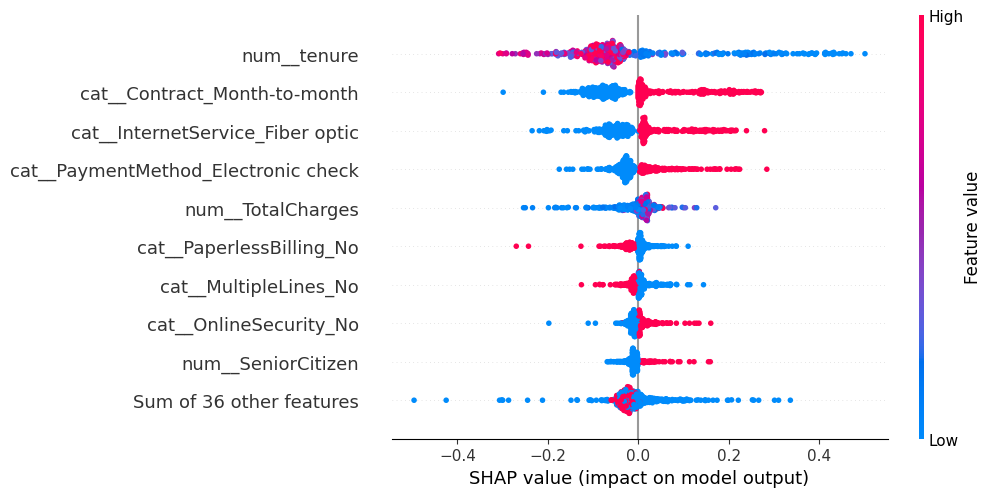

In [61]:
shap.plots.beeswarm(shap_values)

plt.show()

## Dependence Plot

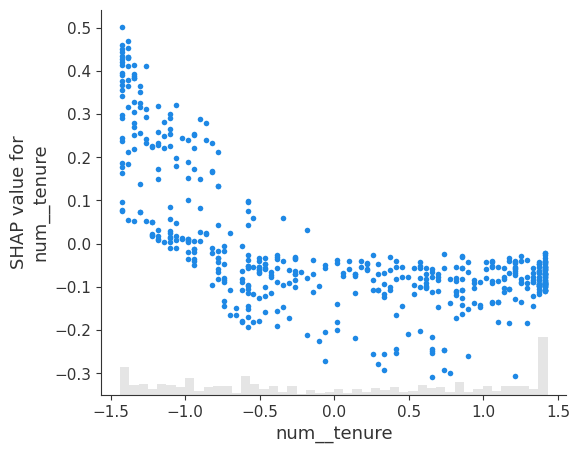

In [62]:
shap.plots.scatter(
    shap_values[:, "num__tenure"]
)

## Waterfall Plot for Single Customer

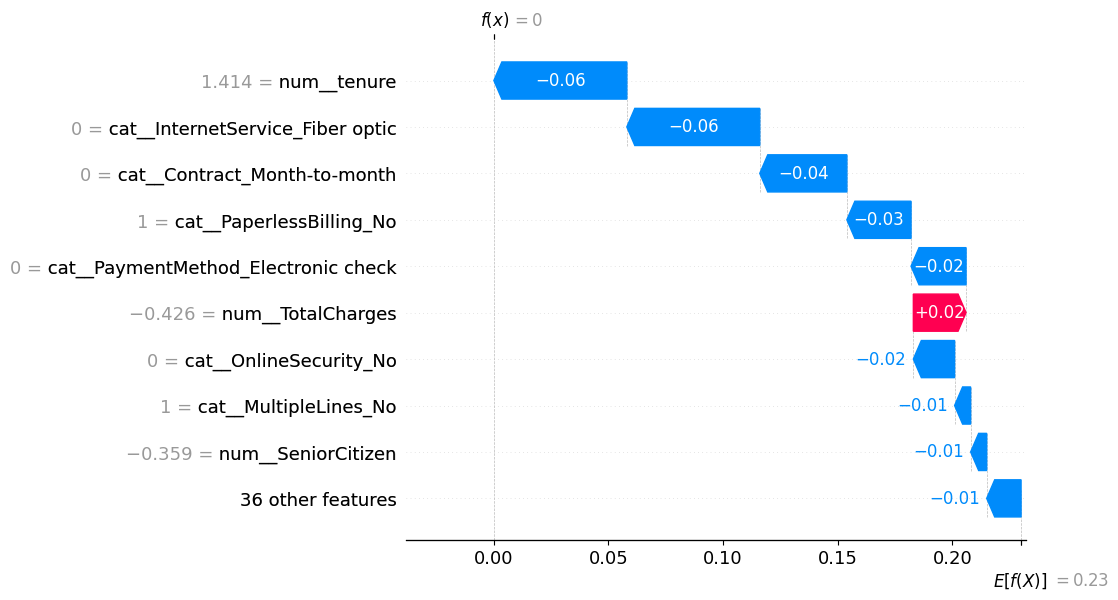

In [63]:
shap.plots.waterfall(shap_values[0])

## Create Submission File

In [ ]:
submission = pd.DataFrame({
    'customerID': test['customerID'],
    'Churn_Probability': test_probs
})

submission.to_csv("submission.csv", index=False)

# Mutual Information Scores

In [ ]:
X = df.copy()
y = X.pop("price")

# Label encoding for categoricals
for colname in X.select_dtypes("object"):
    X[colname], _ = X[colname].factorize()

# All discrete features should now have integer dtypes (double-check this before using MI!)
discrete_features = X.dtypes == int

In [ ]:
def make_mi_scores(X, y, discrete_features):
    mi_scores = mutual_info_regression(X, y, discrete_features=discrete_features)
    mi_scores = pd.Series(mi_scores, name="MI Scores", index=X.columns)
    mi_scores = mi_scores.sort_values(ascending=False)
    return mi_scores

mi_scores = make_mi_scores(X, y, discrete_features)
mi_scores[::3]  # show a few features with their MI scores

In [ ]:
def plot_mi_scores(scores):
    scores = scores.sort_values(ascending=True)
    width = np.arange(len(scores))
    ticks = list(scores.index)
    plt.barh(width, scores)
    plt.yticks(width, ticks)
    plt.title("Mutual Information Scores")


plt.figure(dpi=100, figsize=(8, 5))
plot_mi_scores(mi_scores)

In [ ]:
sns.relplot(x="curb_weight", y="price", data=df);